In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('../data/sample_car_contracts.csv')
df.head()

,id,customer_name,contract_type,vehicle_type,monthly_emi,interest_rate,tenure_months,clause_summary,risk_flag,issue_type,recommended_action
0,1,Rahul Mehta,Car Loan,Sedan,18500,9.5,48,Prepayment allowed only after 24 months with 5...,medium,High prepayment charges,Highlight prepayment penalty to user and sugge...
1,2,Anita Rao,Car Lease,SUV,22000,0.0,36,Lessee must pay for all maintenance and insurance,low,Standard maintenance clause,"No action, just explain maintenance responsibi..."
2,3,James Wilson,Car Loan,Hatchback,14500,11.2,60,Late payment fee of 3% per month on outstandin...,high,Aggressive late fee,Flag clause and suggest user request cap on la...
3,4,Meena Iyer,Car Lease,Sedan,21000,0.0,24,"Excess mileage charge of ₹12 per km over 15,00...",medium,High excess mileage rate,Warn user about extra mileage charges and reco...
4,5,Arjun Patel,Car Loan,SUV,27500,10.8,72,Floating interest rate linked to lender's inte...,high,Unclear interest benchmark,Explain floating rate risk and suggest asking ...


In [3]:
df["contract_length"]=df["clause_summary"].apply(lambda x: len(str(x).split()))
df[["clause_summary" , "contract_length"]]

,clause_summary,contract_length
0,Prepayment allowed only after 24 months with 5...,9
1,Lessee must pay for all maintenance and insurance,8
2,Late payment fee of 3% per month on outstandin...,10
3,"Excess mileage charge of ₹12 per km over 15,00...",12
4,Floating interest rate linked to lender's inte...,8
5,Early termination fee equal to 6 months of EMI,9
6,No foreclosure charges after 12 months,6
7,Battery warranty covered only for 24 months or...,10
8,Mandatory bundled insurance from lender at non...,8
9,"Security deposit of 3 EMIs, refundable at end ...",14


In [4]:

keywords=["fee","penalty","late","extra"]
df["hidden_charges_flag"]=df["clause_summary"].apply(
    lambda x: [word for word in keywords if word in x]
)
df[["clause_summary", "hidden_charges_flag"]]

,clause_summary,hidden_charges_flag
0,Prepayment allowed only after 24 months with 5...,[penalty]
1,Lessee must pay for all maintenance and insurance,[]
2,Late payment fee of 3% per month on outstandin...,[fee]
3,"Excess mileage charge of ₹12 per km over 15,00...",[]
4,Floating interest rate linked to lender's inte...,[]
5,Early termination fee equal to 6 months of EMI,[fee]
6,No foreclosure charges after 12 months,[]
7,Battery warranty covered only for 24 months or...,[]
8,Mandatory bundled insurance from lender at non...,[]
9,"Security deposit of 3 EMIs, refundable at end ...",[]


In [5]:
# Updated keywords list to include 'penality' and 'extraa'
keywords_extended = ["fee", "penalty", "late", "extra", "penality", "extraa"]

df["hidden_charges_flag_extended"] = df["clause_summary"].apply(
    lambda x: [word for word in keywords_extended if word in x]
)
df[["clause_summary", "hidden_charges_flag_extended"]]

,clause_summary,hidden_charges_flag_extended
0,Prepayment allowed only after 24 months with 5...,[penalty]
1,Lessee must pay for all maintenance and insurance,[]
2,Late payment fee of 3% per month on outstandin...,[fee]
3,"Excess mileage charge of ₹12 per km over 15,00...",[]
4,Floating interest rate linked to lender's inte...,[]
5,Early termination fee equal to 6 months of EMI,[fee]
6,No foreclosure charges after 12 months,[]
7,Battery warranty covered only for 24 months or...,[]
8,Mandatory bundled insurance from lender at non...,[]
9,"Security deposit of 3 EMIs, refundable at end ...",[]


In [7]:
from collections import Counter

# Filter high-risk contracts
high_risk_df = df[df["risk_flag"] == "high"]

# Extract all words from clause_summary in high-risk contracts
all_clauses = " ".join(high_risk_df["clause_summary"].str.lower())

# Count word frequency
keyword_counts = Counter(all_clauses.split())

# Display most common keywords
print("Top 20 most frequent keywords in high-risk contracts:")
print(keyword_counts.most_common(20))

Top 20 most frequent keywords in high-risk contracts:
[('fee', 2), ('of', 2), ('to', 2), ('late', 1), ('payment', 1), ('3%', 1), ('per', 1), ('month', 1), ('on', 1), ('outstanding', 1), ('amount', 1), ('floating', 1), ('interest', 1), ('rate', 1), ('linked', 1), ("lender's", 1), ('internal', 1), ('benchmark', 1), ('early', 1), ('termination', 1)]


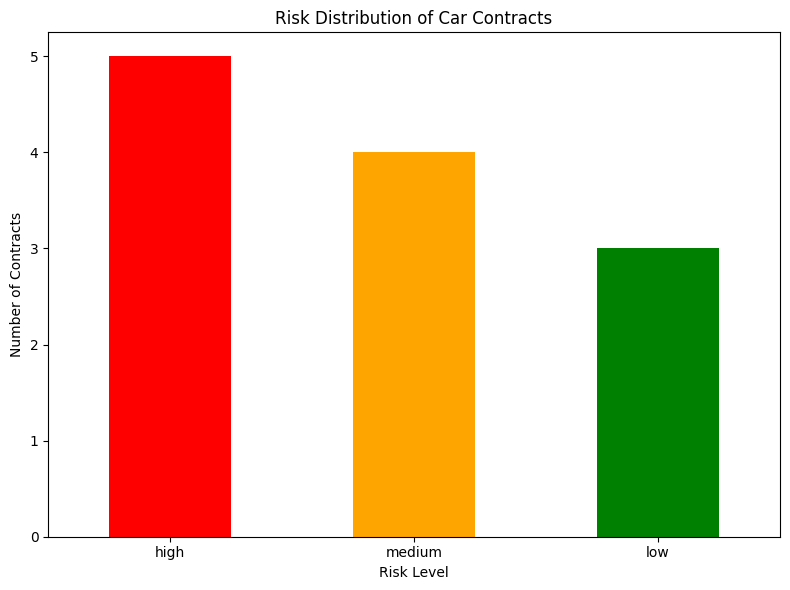

In [8]:
# Plot bar chart of risk distribution
risk_distribution = df["risk_flag"].value_counts()

plt.figure(figsize=(8, 6))
risk_distribution.plot(kind='bar', color=['red', 'orange', 'green'])
plt.title('Risk Distribution of Car Contracts')
plt.xlabel('Risk Level')
plt.ylabel('Number of Contracts')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()